**İki Boyutta (2D) Navigasyon**

İki boyutta (2D) navigasyona geçerken ilk yapmamız gereken şey, kartezyen koordinat sistemi ile navigasyon/denizcilik dünyasındaki açı tanımları arasındaki farkı oturtmaktır. Zira kafaların en çok karıştırdığı nokta burasıdır. 😃

--------------------------------------

**BÖLÜM 1: Navigasyon Tanımları (Açı ve Heading)**

Matematikte ve fizikte açıları X ekseninden saat yönünün tersine tanımlarız. Ancak navigasyonda referans noktası Kuzey (Y ekseni) ve yön Saat Yönüdür.

Yönelim / Rota (Heading - $\psi$ veya $\theta$): Aracın burnunun baktığı açı.
- 0° / 360°: Tam Kuzey ($+Y$)
- 90°: Tam Doğu ($+X$)
- 180°: Tam Güney ($-Y$)
- 270°: Tam Batı ($-X$)


Hız Bileşenleri: Bir $v$ hızıyla $\psi$ açısında giden bir aracın Doğu ($v_x$) ve Kuzey ($v_y$) hız bileşenleri trigonometrik olarak şöyle ayrışır:
$$v_x = v \cdot \sin(\psi)$$
$$v_y = v \cdot \cos(\psi)$$

BÖLÜM 2: 2D Alfa-Beta Filtresi Matematiksel Modeli

Durum vektörümüz (state vector) artık 4 elemanlıdır:

$$X = \begin{bmatrix} x \\ y \\ v_x \\ v_y \end{bmatrix}$$

Tahmin Denklemleri (Prediction):

$x_{pred} = x + v_x \cdot \Delta t$

$y_{pred} = y + v_y \cdot \Delta t$

$v_{x, pred} = v_x$

$v_{y, pred} = v_y$

Güncelleme Denklemleri (Update):

Ölçüm kalıntıları ($r_x, r_y$) iki eksen için ayrı ayrı hesaplanır ve filtre her eksene bağımsız olarak uygulanır:

$x_{est} = x_{pred} + \alpha \cdot r_x$

$y_{est} = y_{pred} + \alpha \cdot r_y$

$v_{x, est} = v_{x, pred} + \left(\frac{\beta}{\Delta t}\right) \cdot r_x$

$v_{y, est} = v_{y, pred} + \left(\frac{\beta}{\Delta t}\right) \cdot r_y$

-----------------------------


**BÖLÜM 3: Python Uygulaması**


In [1]:
# Buraya kod yazacağız

import numpy as np

# 1. TEMEL DÖNÜŞÜM FONKSİYONU
def heading_to_velocity(speed, heading_deg):
    """
    Kuzeye göre derece cinsinden verilen Heading açısını
    Vx (Doğu) ve Vy (Kuzey) bileşenlerine ayırır.
    """
    heading_rad = np.radians(heading_deg)
    vx = speed * np.sin(heading_rad)  # Doğu bileşeni
    vy = speed * np.cos(heading_rad)  # Kuzey bileşeni
    return vx, vy

# 2. 2D ALFA-BETA FİLTRE SINIFI / ADIMLARI
class AlphaBetaFilter2D:
    def __init__(self, alpha, beta, dt):
        self.alpha = alpha
        self.beta = beta
        self.dt = dt

        # Durumlar: [x, y, vx, vy]
        self.x = 0.0
        self.y = 0.0
        self.vx = 0.0
        self.vy = 0.0

    def predict(self):
        # 2D Tahmin adımı
        x_pred = self.x + self.vx * self.dt
        y_pred = self.y + self.vy * self.dt
        vx_pred = self.vx
        vy_pred = self.vy
        return x_pred, y_pred, vx_pred, vy_pred

    def update(self, z_x, z_y):
        # 1. Tahmin et
        x_pred, y_pred, vx_pred, vy_pred = self.predict()

        # 2. Kalıntıları hesapla (Residuals)
        rx = z_x - x_pred
        ry = z_y - y_pred

        # 3. Güncelle
        self.x = x_pred + self.alpha * rx
        self.y = y_pred + self.alpha * ry
        self.vx = vx_pred + (self.beta / self.dt) * rx
        self.vy = vy_pred + (self.beta / self.dt) * ry

        return self.x, self.y, self.vx, self.vy

# TEST: Araç 45 derece (Kuzeydoğu) rotasında 10 m/s hızla gidiyor
speed = 10.0      # m/s
heading = 45.0    # Kuzeyden 45 derece Doğuya
vx_true, vy_true = heading_to_velocity(speed, heading)

print(f"Gerçek Hız Bileşenleri -> Doğu (Vx): {vx_true:.2f} m/s, Kuzey (Vy): {vy_true:.2f} m/s")

Gerçek Hız Bileşenleri -> Doğu (Vx): 7.07 m/s, Kuzey (Vy): 7.07 m/s


**BÖLÜM 4: 2D Rota Takip Simülasyonu ve Görselleştirme**

Şimdi aracı 45° açıyla hareket ettirip 2D düzlemde GPS benzeri gürültülü konum ölçümleri üzerinden takip edelim:

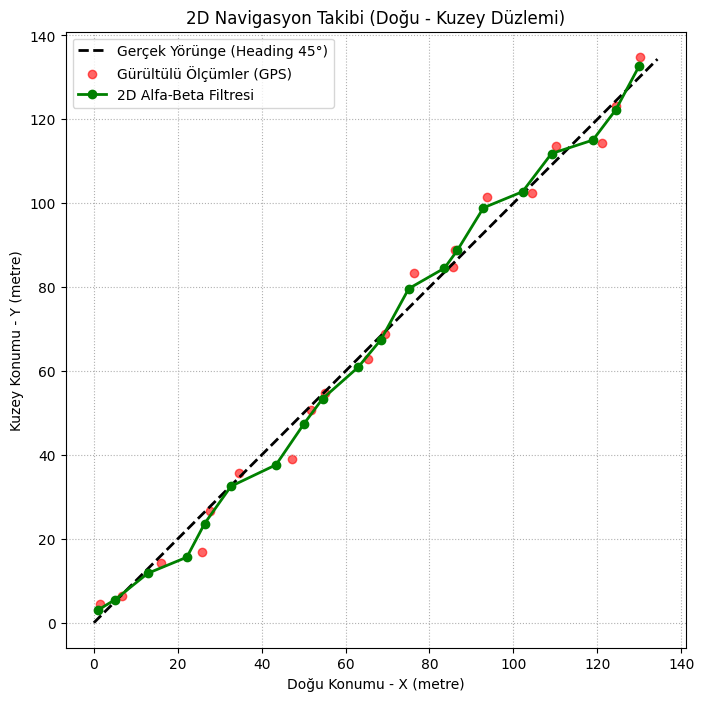

In [2]:
import matplotlib.pyplot as plt

# Simülasyon Parametreleri
dt = 1.0
num_steps = 20
np.random.seed(42)

# Gerçek Yörünge Oluşturma
true_x = [0.0]
true_y = [0.0]
for _ in range(1, num_steps):
    true_x.append(true_x[-1] + vx_true * dt)
    true_y.append(true_y[-1] + vy_true * dt)

# Gürültülü Ölçümler (Sensör)
meas_x = np.array(true_x) + np.random.normal(0, 3.0, num_steps)
meas_y = np.array(true_y) + np.random.normal(0, 3.0, num_steps)

# Filtreyi Çalıştırma
ab_filter = AlphaBetaFilter2D(alpha=0.7, beta=0.05, dt=dt)
est_x, est_y = [], []

for zx, zy in zip(meas_x, meas_y):
    fx, fy, _, _ = ab_filter.update(zx, zy)
    est_x.append(fx)
    est_y.append(fy)

# Plotting
plt.figure(figsize=(8, 8))
plt.plot(true_x, true_y, 'k--', label='Gerçek Yörünge (Heading 45°)', linewidth=2)
plt.scatter(meas_x, meas_y, color='red', alpha=0.6, label='Gürültülü Ölçümler (GPS)')
plt.plot(est_x, est_y, 'g-o', label='2D Alfa-Beta Filtresi', linewidth=2)

plt.title("2D Navigasyon Takibi (Doğu - Kuzey Düzlemi)")
plt.xlabel("Doğu Konumu - X (metre)")
plt.ylabel("Kuzey Konumu - Y (metre)")
plt.axis('equal')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()